In [14]:
import numpy as np
import pandas as pd
import scipy.stats as sps
import matplotlib.pyplot as plt 
from statsmodels.stats.weightstats import _zconfint_generic, _tconfint_generic
import statsmodels.api as sm
import math
%matplotlib inline

# 10 Снова о доверительных интервалах

**1. [# 10]** Известно, что разливочная машина наполняет винные бутылки объёмом вина, которое соответствует распределению $N(\mu, \sigma^2)$, при $\sigma = 5(мл)$. Какой размер выборки необходим, если мы хотим получить 99% доверительный интервал для $\mu$ шириной не более 1 мл?

In [2]:
z_score = sps.norm.ppf(0.99)

sigma = 5 
margin_error = 1

sample_size = ((2 * z_score * sigma) / margin_error) ** 2
print("Необходимый размер выборки:", round(sample_size))

Необходимый размер выборки: 541


**2. [# 25]** Данные по количеству альфа-частиц приведены в задании 9.4. Зная, что количество выбросов α-частиц в течение определенного интервала имеет распределение Пуассона, мы можем рассматривать эти данные как наблюдения из распределения $Pois(\mu)$. Центральная предельная теорема говорит нам, что среднее значение $X_{n}$ для большого числа независимых объектов $Pois(\mu)$ приблизительно имеет нормальное распределение и, следовательно, <br>
$\frac{\overline{X}_{n}-\mu}{\sqrt{\mu}/\sqrt{n}}$ <br>
имеет распределение, которое приблизительно равно $N(0, 1)$.

In [3]:
count = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
frequency = [57, 203, 383, 525, 532, 408, 273, 139, 45, 27, 10, 4, 0, 1, 1]

df_alpha_particle = []
for c, f in zip(count, frequency):
    df_alpha_particle.extend([c] * f)
    
df_alpha_particle = pd.DataFrame(df_alpha_particle, columns=['alpha'])

mean = df_alpha_particle.alpha.mean()
std = df_alpha_particle.alpha.std()

**a.** Покажите, что 95%−ный доверительный интервал большой выборки содержит те значения $\mu$, для которых $(\overline{x}_{n} − \mu)^2 ≤ (1.96)^2 \frac{\mu}{n}$

In [4]:
sample_mean = df_alpha_particle['alpha'].mean()
sample_std = df_alpha_particle['alpha'].std()

n = len(df_alpha_particle)

bound = (1.96) ** 2 * sample_mean / n

print("Значение (1.96)^2 * mu / n:", bound)

Значение (1.96)^2 * mu / n: 0.005702815546313372


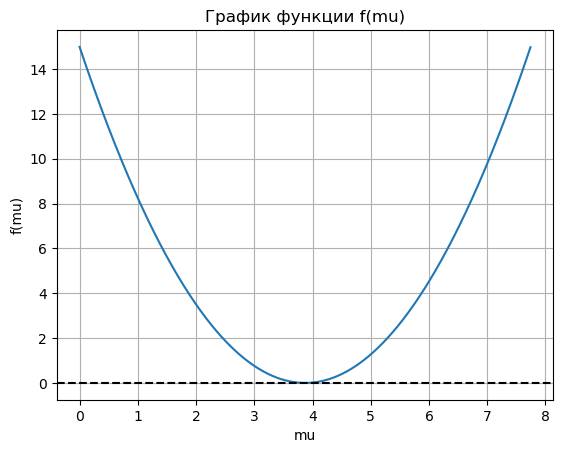

In [5]:
def f(mu):
    return (sample_mean - mu) ** 2 - (1.96) ** 2 * mu / n

mus = np.linspace(0, sample_mean * 2, 1000)
results = [f(mu) for mu in mus]

plt.plot(mus, results)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('mu')
plt.ylabel('f(mu)')
plt.title('График функции f(mu)')
plt.grid(True)
plt.show()

**б.** Используйте результат из пункта а для построения 95% доверительного интервала
для большой выборки на основе этих данных.

In [6]:
sample_mean = df_alpha_particle['alpha'].mean()
n = len(df_alpha_particle)

lower_bound = sample_mean - 1.96 * np.sqrt(sample_mean / n)
upper_bound = sample_mean + 1.96 * np.sqrt(sample_mean / n)

print("95% доверительный интервал для большой выборки:")
print("Нижняя граница:", lower_bound)
print("Верхняя граница:", upper_bound)

95% доверительный интервал для большой выборки:
Нижняя граница: 3.796032091292975
Верхняя граница: 3.9470660682162273


**в.** Сравните результат с результатом упражнения 9.4.

In [8]:
# Результаты из упражнения 9.4
print("98% доверительный интервал для среднего (3.78, 3.95)")

# Мои результаты
sample_mean = df_alpha_particle['alpha'].mean()
n = len(df_alpha_particle)

lower_bound = sample_mean - 1.96 * np.sqrt(sample_mean / n)
upper_bound = sample_mean + 1.96 * np.sqrt(sample_mean / n)

print("95%% доверительный интервал для большой выборки: (%.2f, %.2f)" % (lower_bound, upper_bound))

98% доверительный интервал для среднего (3.78, 3.95)
95% доверительный интервал для большой выборки: (3.80, 3.95)


__3. [# 30]__ Во время зимних Олимпийских игр 2002 года в Солт-Лейк-Сити в газетной статье упоминалось о предполагаемом преимуществе конькобежцев в беге на 1500 метров, если они стартуют на внешней дорожке. В беге на 1500 м у мужчин было 24 забега. Данные приведены в таблице speed_skating.xlsx. <br>
Если бы не было преимущества на внешней полосе, количество из 24 завершенных заездов, выигранных фигуристами, стартовавшими на внешней полосе, распределилось бы по $Bin(23, p)$ с $p$ = 1/2, из-за распределения полосы путем лотереи.

**а.** Из 23 заездов 15 были выиграны фигуристом, стартовавшим на внешней дорожке. Используйте эту информацию, чтобы рассчитать 95% доверительный интервал для $p$ с помощью метода Уилсона. Если вы считаете, что $n$ = 23, вероятно, слишком мало для использования метода, основанного на центральной предельной теореме, мы согласны. Нам следует быть осторожными с выводами, которые мы делаем на основе этого доверительного интервала.

In [17]:
x = 15 
n = 23

ci_wilson = sm.stats.proportion_confint(x, n, alpha=0.05, method='wilson')

print("95% доверительный интервал методом Уилсона:", ci_wilson)

95% доверительный интервал методом Уилсона: (0.44890335377263, 0.8118872406120227)


**б.** Заданный ранее вопрос «Есть ли преимущество на внешней полосе движения?» подразумевает, что более подходящим является односторонний доверительный интервал. Постройте соответствующий 95%-ный односторонний доверительный интервал для $p$, сначала построив 90%-ный двусторонний доверительный интервал.

In [16]:
ci_90_wilson = sm.stats.proportion_confint(x, n, alpha=0.1, method='wilson')

lower_bound_90 = ci_90_wilson[0]

ci_one_sided = (lower_bound_90, 1)

print("95% односторонний доверительный интервал:", ci_one_sided)

95% односторонний доверительный интервал: (0.48081238593470593, 1)
